In [3]:
#Imports

import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import pickle
import seaborn as sns
from matplotlib.ticker import MaxNLocator



In [ ]:

task = '2AB'

#extract data
with open('./data/all_sub_2ab.pickle', 'rb') as handle:
    all_sub_2ab = pickle.load(handle)

subs = all_sub_2ab.keys()

excluded_subs = []
for sub in tqdm(subs) : 
    df= all_sub_2ab[sub]
    df= df.drop(df.index[0:25])
    switch = np.array((df['choice'] != df['choice'].shift()).cumsum())[-1]
    if switch < 2 : 
        excluded_subs.append(sub) 
    
subs = [sub for sub in subs if sub not in excluded_subs]
    

100%|██████████| 258/258 [00:00<00:00, 4078.74it/s]


In [4]:
font = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

yfont = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }
xfont = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }


tick_fontsize = 17
col = ['#FF5733', '#3498DB']
legend_fontsize = 20

In [5]:
def sigmoid(x, L, x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return y

def p_switch(df):
    pswitch = np.mean(np.diff(df['choice']) != 0)
    return pswitch

#### Plot B 
Walk + choice

In [25]:
Sub= subs[np.random.randint(0, len(subs))]

df= all_sub_2ab[Sub]
df= df.drop(df.index[0:25]).reset_index(drop=True)
choice= df['choice']
x= np.arange(len(choice))
arm1 = df['arm1']
arm2 = df['arm2']


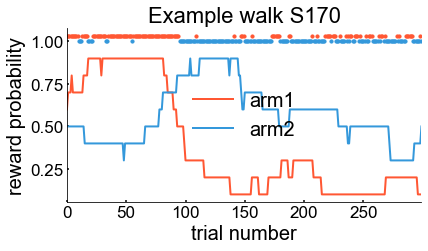

In [27]:

# Sub=202
# Fig settings
showlegend = True

dot_size = 10

# Create figure and axes for subplots
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6.5, 4), sharex=True)

# Plot walk

ax.plot(x, arm1, linestyle='-', linewidth = 2, color=col[0], label='arm1')
ax.plot(x, arm2, linestyle='-', linewidth = 2, color=col[1], label='arm2')

# Add choice
for i in range(len(choice)):
    if choice[i] == 0:
        ax.scatter(x[i], choice[i]+1.03, color=col[0], s=dot_size, label='_nolegend_')
    else:
        ax.scatter(x[i], choice[i], color=col[1], s=dot_size, label='_nolegend_')

# Update layout
if showlegend:
    ax.legend(frameon=False, loc='best', fontsize=legend_fontsize)

ax.set_title('Example walk S' + f'{Sub}', loc='center',fontdict=font)
ax.set_xlabel('trial number', fontdict=xfont)
ax.set_ylabel('reward probability', fontdict=yfont)

# Adjust layout for readability
fig.tight_layout()

ax = plt.gca()
ax.margins(x=0)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tick_params(axis='both', which='major', 
                    labelsize=tick_fontsize, direction='in',
                    length= 2,
                    width=1.5)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = xfont['size']
# plt.xlim([0,20])
plt.show()

# Save figure in folder
fig.savefig(f"{fig_dir}{task}Example_walk_{Sub}.pdf", format="pdf")


#### PLOT C 

Average probability of choosing option 1 as a function of the difference in the objective reward probability (“value”) between option 1 and 2


In [9]:
#add difference vector in each dataframe
'''diff_vector is equal to p_option 1 - p_option 2'''

concat_choice1= pd.DataFrame()
for sub in subs : 
    df= all_sub_2ab[sub]
    df = df.drop(df.index[0:25]).reset_index(drop=True)
    df['diff_vector'] = df['arm1']- df['arm2']
    
    sum_in_bin = df.groupby(['diff_vector']).size()
    p_choice = df.groupby(['diff_vector', 'choice']).size()/sum_in_bin
    new_df = p_choice.reset_index()
    #mean of choice = 0 (option 1)
    choice_1_df = new_df[new_df['choice'] == 0] #choice 1 
    concat_choice1 = pd.concat([concat_choice1, choice_1_df], ignore_index=True)  # concatenate and reset index
    

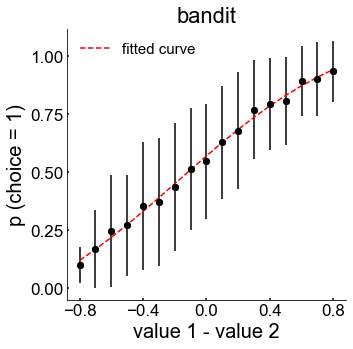

In [10]:

concat_choice1['diff_vector'] = concat_choice1['diff_vector'].round(1)
x = np.unique(concat_choice1['diff_vector'])
y_means = concat_choice1.groupby('diff_vector')[0].mean()
y_std = concat_choice1.groupby('diff_vector')[0].std()

plt.figure(figsize=(5, 5))
popt, pcov = curve_fit(sigmoid, x, y_means)
plt.errorbar(x, y_means, yerr=y_std, fmt='ko', capsize=0)

#Fit sigmoid
title = 'bandit'
plt.title(title, fontdict=font)
plt.plot(x, y_means, 'ko')
plt.plot(x, sigmoid(x,*popt), 'r--', label='fitted curve')
plt.xlabel('value 1 - value 2',fontdict=xfont)
plt.ylabel('p (choice = 1)', fontdict=yfont)
plt.gca().xaxis.set_major_locator(MaxNLocator( nbins=5 ))
plt.gca().yaxis.set_major_locator(MaxNLocator( nbins=5))

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tick_params(axis='both', which='major', 
                    labelsize=tick_fontsize, direction='in',
                    length= 2,
                    width=1.5)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'arial'

#save
plt.legend(fontsize = 15, frameon=False, loc="upper left")

title= "pchoice"
plt.savefig(f'{fig_dir}{task}{title}.svg', format='svg')
plt.show()



#### PLOT D
Distribution of the percent of trials in which each subject (gray bars) chose the objectively best option. Dotted line = chance, carrot = mean across subjects.

In [ ]:

accumulated_hist = None
best_list = []
best_rewarded_list = []
mean_rwd_list = [] 

for sub in subs : 
    df= all_sub_2ab[sub]
    df = df.drop(df.index[0:25]).reset_index(drop=True)
    df['best_option'] = (df['arm1'] < df['arm2']).astype(int)
    df.loc[df['arm1'] == df['arm2'], 'best_option'] = df['choice'] # best option is chosen option if =

    #objectively best option 
    best_fraction = len(df.loc[(df['best_option'] == df['choice'])])/len(df)
    chance = np.mean((df.arm1 + df.arm2) / 2)
    best_fraction_rewarded = len(df.loc[ (df['reward']==1)])/len(df)
    
    best_list.append(best_fraction)
    
    best_rewarded_list.append((best_fraction_rewarded-chance)/chance)
    mean_rwd_list.append(round(df['reward'].mean(), 2))
    
        
    
   


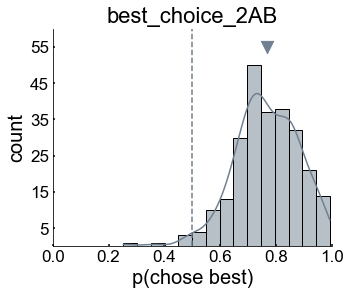

In [135]:
c = "slategrey"
plt.figure(figsize=(5,4))
sns.histplot(best_list, bins=15, stat= 'count', kde=True, label='Best choice', color=c)
plt.axvline(x=0.5, color=c, linestyle='--')
plt.scatter(np.mean(best_list),55, marker='v', s=150, c=c)

title = f'best_choice_{task}'
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tick_params(axis='both', which='major', 
                    labelsize=tick_fontsize, direction='in',
                    length= 2,
                    width=1.5)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'arial'
            
plt.title(title, fontdict=font)
# plt.legend(fontsize = legend_fontsize,frameon=False)
plt.xlabel('p(chose best)', color='black', fontdict=xfont)
plt.ylabel('count', color='black', fontdict=yfont)
plt.xlim([0,1])
plt.ylim([0,60])
ax.set_yticks(np.arange(5,60,10))

plt.savefig(f'{fig_dir}{task}{title}.svg', format='svg')

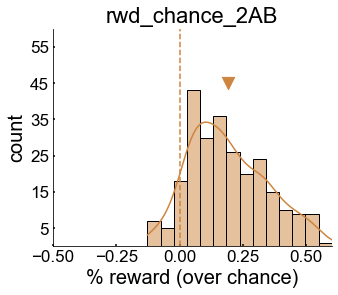

In [26]:
c = 'peru'
plt.figure(figsize=(5,4))
sns.histplot(best_rewarded_list,  bins=15,stat= 'count' , kde=True, label='rewarded over chance', color=c)
plt.axvline(x=0, color=c, linestyle='--')
plt.scatter(np.mean(best_rewarded_list),45, marker='v', s=150, c=c)
title = f'rwd_chance_{task}'
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tick_params(axis='both', which='major', 
                    labelsize=tick_fontsize, direction='in',
                    length= 2,
                    width=1.5)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'arial'

plt.title(title, fontdict=font)
# plt.legend(fontsize = legend_fontsize,frameon=False, loc="upper left")
plt.xlabel('% reward (over chance)', color='black', fontdict=xfont)
plt.ylabel('count', color='black', fontdict=yfont)
plt.xlim([-0.5,0.6])
plt.ylim([0,60])

ax.set_yticks(np.arange(5,60,10))
plt.savefig(f'{fig_dir}{task}{title}.svg', format='svg')

#### STATS

In [92]:
switch_list = [] 
for sub in subs : 
    df= all_sub_2ab[sub]
    df = df.drop(df.index[0:25]).reset_index(drop=True)
    switch_list.append(p_switch(df))

wsls = np.empty((3, len(subs)))

for i , sub in enumerate(subs) : 
    df= all_sub_2ab[sub]
    df = df.drop(df.index[0:25]).reset_index(drop=True)

    
    choices = np.array(df['choice'])
    rewards = np.array(df['reward'])
    switches = np.diff(choices) != 0
    
    rewards = rewards[:-1]  # Aligning rewards length with switches

    wsls[0, i] = p_switch(df)
   
    wsls[1, i] = np.nanmean(switches[rewards == 1] == 0) # win stay
    wsls[2, i] = np.nanmean(switches[rewards == 0] == 1) #lose shift



In [95]:
print("% ojective best option mean =" , round(np.mean(best_list)*100,1) ) 
print("% ojective best option std =", round(np.std(best_list)*100,1) ) 
print("% rwd over chance mean =",round(np.mean(best_rewarded_list)*100,1) )
print("% rwd over chance std =", round(np.std(best_rewarded_list)*100,1))
print("% switch mean=", round(np.mean(switch_list)*100,1))
print("% switch std=", round(np.std(switch_list)*100,1))
print("% win-stay mean=", round(np.mean(wsls[1,:])*100,1))
print("% win-stay std=", round(np.std(wsls[1,:])*100,1))
print("% loose-shift mean=", round(np.mean(wsls[2,:])*100,1))
print("% loose-shift  std=", round(np.std(wsls[2,:])*100,1))

% ojective best option mean = 76.6
% ojective best option std = 11.5
% rwd over chance mean = 19.2
% rwd over chance std = 15.3
% switch mean= 19.9
% switch std= 14.5
% win-stay mean= 93.3
% win-stay std= 11.1
% loose-shift mean= 39.2
% loose-shift  std= 21.0
